# The current assessment roll is published under the wrong coverage year

**Dataset:** *Property Assessment Data (Current Calendar Year)*, `q7d6-ambg`
on `data.edmonton.ca`.

**In one sentence:** the dataset's `Period of Coverage` metadata reads
*2025-01-01 to 2025-12-31*, but the rows in it are the **2026** assessment
roll — and the field has been stale for the whole of the 2026 roll.

The data itself is not in question. Only the label is wrong, and the fix is a
single metadata edit. This notebook exists because that label is the only
machine-readable statement of which tax year the file describes, so a consumer
who trusts it mis-dates every number they derive from it.

## The one methodological point worth reading even if nothing else

**A publisher's metadata field is a claim about the data, not a measurement of
it.** Nothing inside `q7d6-ambg` states its own year, so the only way to check
the label is to compare the contents against a source whose year is known
independently.

Two such comparisons are run below, and they are deliberately of different
kinds:

- **§2 uses only Edmonton's own data.** The *Historical* assessment dataset
  (`qi6a-xuwt`) carries a 2025 slice. If the current roll were also 2025, the
  two would broadly agree. They do not.
- **§3 uses a source outside the City entirely** — what Edmonton filed with
  the Province of Alberta. That rules out the possibility that both Edmonton
  datasets are simply labelled with the same error.

Either check alone identifies the year. Together they leave no reading in
which the current roll is 2025.

## Reproducing

```
pip install pandas matplotlib certifi openpyxl
```

§1 and §2 are four aggregate queries and run in seconds. §3 downloads two
spreadsheets from `open.alberta.ca` (~10 MB) and caches them. No API token is
needed for any of it.

In [1]:
import base64
import io
import json
import os
import re
import ssl
import urllib.parse
import urllib.request
from pathlib import Path

import certifi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import HTML, Markdown, display

SSL_CTX = ssl.create_default_context(cafile=certifi.where())
# ⚠️ open.alberta.ca rejects urllib's default User-Agent with 403. Both hosts
# get a real one here; data.edmonton.ca does not require it but is consistent.
UA = "Mozilla/5.0 (compatible; edmonton-roll-year-report/1.0)"

CURRENT = "q7d6-ambg"      # Property Assessment Data (Current Calendar Year)
HISTORICAL = "qi6a-xuwt"   # Property Assessment Data (Historical)

# ⚠️ Every numeric column in q7d6-ambg is typed `text` on Socrata, so an
# unguarded sum() returns HTTP 400 rather than a wrong answer. The `::number`
# casts below are load-bearing, not cosmetic.
CAST = "::number"

CACHE = Path(os.environ.get("ROLL_YEAR_DATA", "./roll_year_data")).resolve()
CACHE.mkdir(parents=True, exist_ok=True)

# ⚠️ THIS REPORT IS A SNAPSHOT, and the published page has to say so on its own
# face — it is the artifact that gets handed to someone, usually without the
# index page that would otherwise date it. Two of these four carried NO date at
# all until 2026-08-29.
#
# FIRST_MEASURED is when the finding was made and does NOT change on re-run.
# _STAMPED_AT is when this page was last re-executed against live data. Both are
# shown: "first found on" and "still true today" are different claims and a
# reader needs each. Imports are aliased and local to this block so it can be
# pasted into any of these notebooks unchanged.
import datetime as _dt

from IPython.display import Markdown as _Md, display as _disp

FIRST_MEASURED = "2026-08-26"
_STAMPED_AT = _dt.datetime.now(_dt.timezone.utc)

_disp(_Md(
    f"**Snapshot.** Finding first measured **{FIRST_MEASURED}**; this page "
    f"re-executed against live data **{_STAMPED_AT:%Y-%m-%d}** (UTC). "
    f"Nothing re-runs these on a schedule — re-execute before citing a figure."))

CHECKS: list[tuple[bool, str]] = []


def check(ok: bool, claim: str) -> None:
    CHECKS.append((bool(ok), claim))
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")


def _read(url: str, timeout: int = 600) -> bytes:
    req = urllib.request.Request(url, headers={"User-Agent": UA})
    with urllib.request.urlopen(req, context=SSL_CTX, timeout=timeout) as r:
        return r.read()


def soda(dataset: str, params: dict) -> list[dict]:
    """One Socrata query. ⚠️ urlencode is required — a raw space in $select
    (as in `count(*) as n`) raises InvalidURL before the request is made."""
    return json.loads(_read(
        f"https://data.edmonton.ca/resource/{dataset}.json?"
        + urllib.parse.urlencode(params)))


def show(fig, alt: str) -> None:
    """Display a figure carrying real alt text (plt.show() emits none)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, facecolor=fig.get_facecolor())
    plt.close(fig)
    display(HTML(f'<img alt="{alt}" '
                 f'src="data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}">'))


def money(v: float) -> str:
    return f"${v:,.0f}"


print(f"cache: {CACHE}")

**Snapshot.** Finding first measured **2026-08-26**; this page re-executed against live data **2026-09-23** (UTC). Nothing re-runs these on a schedule — re-execute before citing a figure.

cache: /tmp/tmp.gvgCJDbOHA/r


---
## 1. What the dataset says about itself

`Period of Coverage` is a free-text field in the dataset's Socrata metadata.
It is the only place the file's tax year is stated.

In [2]:
meta = json.loads(_read(f"https://data.edmonton.ca/api/views/{CURRENT}.json", timeout=120))

coverage = meta["metadata"]["custom_fields"]["Time Frame"]["Period of Coverage"]
rows_updated = pd.to_datetime(meta["rowsUpdatedAt"], unit="s", utc=True)
coverage_years = sorted({int(y) for y in re.findall(r"\b(20\d{2})\b", coverage)})

display(Markdown(f"""
| field | value |
|---|---|
| dataset | **{meta['name']}** (`{CURRENT}`) |
| `Period of Coverage` | **{coverage}** |
| rows last updated | **{rows_updated:%Y-%m-%d}** |
"""))

# The checks that guard an index come BEFORE it: a verdict recorded after the
# crash it was meant to prevent is never printed, and the recheck then reads a
# changed field as a dead source (❓) instead of a moved one (⚠️).
check(len(coverage_years) > 0, "Period of Coverage names at least one year")
if not coverage_years:
    raise AssertionError("Period of Coverage names no year — see above")
claimed_year = coverage_years[-1]
print(f"\nThe metadata claims the roll covers: {claimed_year}")


| field | value |
|---|---|
| dataset | **Property Assessment Data (Current Calendar Year)** (`q7d6-ambg`) |
| `Period of Coverage` | **2025-01-01 to 2025-12-31** |
| rows last updated | **2026-09-14** |


  [PASS] Period of Coverage names at least one year

The metadata claims the roll covers: 2025


The rows were refreshed recently, so this is not an abandoned dataset — it is
a maintained file carrying a stale hand-entered label.

---
## 2. Edmonton's own two datasets disagree about 2025

The *Historical* dataset (`qi6a-xuwt`) publishes one slice per assessment
year, each one labelled explicitly in an `assessment_year` column. If the
current roll were the 2025 roll, its total assessed value would sit close to
that dataset's 2025 slice.

Both totals below come from Socrata's own aggregation, not from a download
that could be silently truncated.

In [3]:
hist = pd.DataFrame(soda(HISTORICAL, {
    "$select": f"assessment_year, count(*) as n, sum(assessed_value{CAST}) as total",
    "$group": "assessment_year",
    "$order": "assessment_year",
})).astype({"assessment_year": int, "n": int, "total": float})

cur = soda(CURRENT, {"$select": f"count(*) as n, sum(assessed_value{CAST}) as total"})[0]
cur_n, cur_total = int(cur["n"]), float(cur["total"])

# If the City corrects the label to the roll's real year, the historical
# dataset has no slice for it yet — that is the fix, so it fails here.
check((hist.assessment_year == claimed_year).any(),
      f"the historical dataset has a slice for the labelled year {claimed_year}")
if not (hist.assessment_year == claimed_year).any():
    raise AssertionError(f"no historical slice for {claimed_year} — the label may have been corrected")
hist_claimed = hist.loc[hist.assessment_year == claimed_year].iloc[0]
gap = cur_total / hist_claimed.total - 1

display(Markdown(f"""
| source | accounts | total assessed value |
|---|---|---|
| Historical `{HISTORICAL}`, **{claimed_year}** slice | {int(hist_claimed.n):,} | **{money(hist_claimed.total)}** |
| Current roll `{CURRENT}` (labelled {claimed_year}) | {cur_n:,} | **{money(cur_total)}** |
| difference | {cur_n - int(hist_claimed.n):+,} | **{gap:+.1%}** |
"""))

check(abs(gap) > 0.05,
      f"the two datasets differ by more than 5% on the same claimed year ({gap:+.1%})")

  [PASS] the historical dataset has a slice for the labelled year 2025



| source | accounts | total assessed value |
|---|---|---|
| Historical `qi6a-xuwt`, **2025** slice | 431,706 | **$220,070,676,646** |
| Current roll `q7d6-ambg` (labelled 2025) | 439,641 | **$238,408,124,458** |
| difference | +7,935 | **+8.3%** |


  [PASS] the two datasets differ by more than 5% on the same claimed year (+8.3%)


An 8% divergence is not a revision or a rounding difference — it is the size
of a full revaluation. Put the current roll on the historical series and it
does not sit at 2025; it sits a year beyond the end of it.


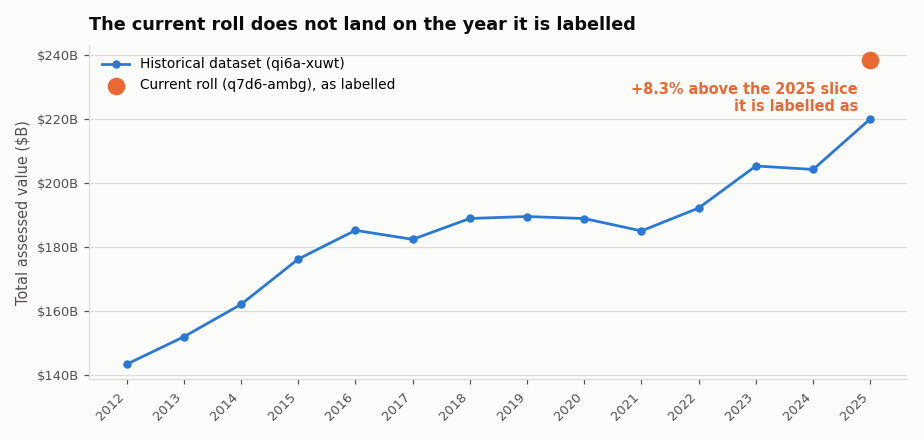

In [4]:
SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd8"
BLUE, ORANGE = "#2a78d6", "#eb6834"   # validated categorical slots 1 and 2

fig, ax = plt.subplots(figsize=(8.4, 4.0), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(hist.assessment_year, hist.total / 1e9, marker="o", ms=4.5,
        color=BLUE, lw=1.8, label=f"Historical dataset ({HISTORICAL})")
ax.scatter([claimed_year], [cur_total / 1e9], s=110, color=ORANGE, zorder=5,
           label=f"Current roll ({CURRENT}), as labelled")

ax.annotate(f"{gap:+.1%} above the {claimed_year} slice\nit is labelled as",
            xy=(claimed_year, cur_total / 1e9),
            xytext=(-8, -14), textcoords="offset points",
            ha="right", va="top", color=ORANGE, fontsize=9.5, fontweight="bold")

ax.set_ylabel("Total assessed value ($B)", color=INK_MUTED, fontsize=9.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B"))
ax.set_xticks(list(hist.assessment_year))
ax.set_xticklabels(list(hist.assessment_year), rotation=45, ha="right", fontsize=8.5)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.tick_params(colors=INK_MUTED, labelsize=8.5)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("The current roll does not land on the year it is labelled",
             color=INK, fontsize=11.5, fontweight="bold", loc="left", pad=10)
plt.tight_layout()
show(fig, f"Line chart of Edmonton's total assessed value by year from the Historical "
          f"dataset, {int(hist.assessment_year.min())} to {int(hist.assessment_year.max())}, "
          f"rising from about ${hist.total.min()/1e9:,.0f}B to "
          f"${hist_claimed.total/1e9:,.0f}B. A separate orange point marks the current "
          f"roll at ${cur_total/1e9:,.0f}B, {gap:+.1%} above the {claimed_year} slice it "
          f"shares a label with, continuing the trend a year past the series end.")

---
## 3. An independent check, from outside the City

§2 shows the two datasets disagree, but not on its own which one is
mislabelled. For that, a source whose year cannot be in doubt: **Alberta's
Financial Information Return (FIR)**, the annual filing every municipality
makes to Municipal Affairs. Schedule `MR(2)` reports the taxable assessment
Edmonton filed, by year and by class.

**Residential is the class to compare on**, because residential land is barely
exempt anywhere — so a roll's residential total should land within a couple of
percent of the filed figure for its own year, and roughly 10% away from any
neighbouring year. That separation is what makes the comparison decisive
rather than suggestive.

In [5]:
FIR_PAGE = "https://open.alberta.ca/opendata/municipal-financial-and-statistical-data"
EDMONTON_CODE, EDMONTON_NAME = "0098", "EDMONTON"
MR_RESIDENTIAL_COL = 5   # header text is asserted below rather than trusted


def fir_workbooks() -> dict[int, str]:
    """financial year -> workbook URL, from the province's dataset page."""
    html = _read(FIR_PAGE, timeout=180).decode("utf-8", "replace")
    out: dict[int, str] = {}
    for u in set(re.findall(r'href="(https://open\.alberta\.ca/dataset/[^"]+)"', html)):
        m = re.search(r"/download/(\d{4})_(?:financial_year|tax_rates)\.xlsx$", u, re.I)
        if m:
            year = int(m.group(1))
            # The full financial filing beats the early tax-rates release.
            if year not in out or "financial_year" in u.lower():
                out[year] = u
    return out


def fir_residential(year: int, url: str) -> float:
    import openpyxl

    dest = CACHE / f"fir_{year}.xlsx"
    if not (dest.exists() and dest.stat().st_size > 0):
        dest.write_bytes(_read(url))
    wb = openpyxl.load_workbook(dest, read_only=True, data_only=True)
    try:
        ws = wb["MR(2)-Assessment"]
        header = next(ws.iter_rows(min_row=2, max_row=2, values_only=True))
        got = str(header[MR_RESIDENTIAL_COL] or "").lower()
        if "residential" not in got:
            raise ValueError(
                f"{year}: MR(2) column {MR_RESIDENTIAL_COL} header is {header[MR_RESIDENTIAL_COL]!r}, "
                "expected to contain 'residential' — the schedule moved, do not read blind")
        for row in ws.iter_rows(values_only=True):
            if any(isinstance(c, str) and c.strip().upper() == EDMONTON_NAME for c in row[:6]):
                if str(row[2]).strip() != EDMONTON_CODE:
                    raise ValueError(f"{year}: {EDMONTON_NAME} under code {row[2]!r}")
                return float(row[MR_RESIDENTIAL_COL])
        raise ValueError(f"{year}: no {EDMONTON_NAME} row in MR(2)")
    finally:
        wb.close()


books = fir_workbooks()
filed = {y: fir_residential(y, u) for y, u in sorted(books.items()) if y >= claimed_year - 2}
print("filed residential assessment (FIR Schedule MR(2)):")
for y, v in sorted(filed.items()):
    print(f"  {y}: {money(v)}")

filed residential assessment (FIR Schedule MR(2)):
  2023: $131,284,317,914
  2024: $134,439,557,008
  2025: $148,128,818,480
  2026: $160,372,669,990


Now the same quantity from the current roll. A parcel can be split across up
to three tax classes, so the residential base is the **apportioned** sum
across all three slots — taking only slot 1 would understate it.

In [6]:
ours = 0.0
for slot in (1, 2, 3):
    v = soda(CURRENT, {
        "$select": f"sum(assessed_value{CAST} * tax_class_pct_{slot}{CAST} / 100) as v",
        "$where": f"mill_class_{slot}='RESIDENTIAL'",
    })[0]["v"]
    part = float(v or 0)
    ours += part
    print(f"  slot {slot}: {money(part)}")
print(f"\napportioned residential base in the current roll: {money(ours)}")

residuals = {y: ours / base - 1 for y, base in filed.items()}
best = min(residuals, key=lambda y: abs(residuals[y]))

display(Markdown(
    "| filed year | FIR residential assessment | current roll vs filed |\n|---|---|---|\n"
    + "\n".join(
        f"| {y} | {money(filed[y])} | **{residuals[y]:+.1%}**"
        + (" ← best fit |" if y == best else " |")
        for y in sorted(filed))))

check(best != claimed_year,
      f"the roll's residential base does NOT best-fit its labelled year "
      f"({claimed_year}: {residuals[claimed_year]:+.1%})")
check(abs(residuals[best]) < 0.05,
      f"it fits {best} within 5% ({residuals[best]:+.1%})")
runner_up = min((y for y in residuals if y != best), key=lambda y: abs(residuals[y]))
check(abs(residuals[runner_up]) - abs(residuals[best]) > 0.03,
      f"and beats the runner-up {runner_up} by more than 3 points "
      f"({abs(residuals[runner_up]) - abs(residuals[best]):.1%})")

  slot 1: $162,202,590,480


  slot 2: $119,010,755


  slot 3: $13,705,630

apportioned residential base in the current roll: $162,335,306,865


| filed year | FIR residential assessment | current roll vs filed |
|---|---|---|
| 2023 | $131,284,317,914 | **+23.7%** |
| 2024 | $134,439,557,008 | **+20.7%** |
| 2025 | $148,128,818,480 | **+9.6%** |
| 2026 | $160,372,669,990 | **+1.2%** ← best fit |

  [PASS] the roll's residential base does NOT best-fit its labelled year (2025: +9.6%)
  [PASS] it fits 2026 within 5% (+1.2%)
  [PASS] and beats the runner-up 2025 by more than 3 points (8.4%)



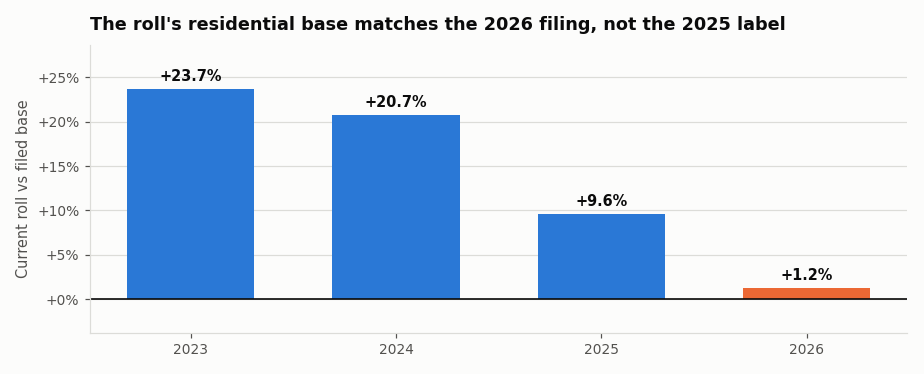

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
years = sorted(residuals)
vals = [100 * residuals[y] for y in years]
colors = [ORANGE if y == best else BLUE for y in years]
bars = ax.bar([str(y) for y in years], vals, color=colors, width=0.62)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + (0.6 if v >= 0 else -1.6),
            f"{v:+.1f}%", ha="center", va="bottom" if v >= 0 else "top",
            fontsize=9.5, fontweight="bold", color=INK)
ax.axhline(0, color=INK, lw=1.1)
ax.set_ylabel("Current roll vs filed base", color=INK_MUTED, fontsize=9.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax.set_ylim(min(vals) - 5, max(vals) + 5)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.set_title(f"The roll's residential base matches the {best} filing, not the "
             f"{claimed_year} label", color=INK, fontsize=11.5,
             fontweight="bold", loc="left", pad=10)
plt.tight_layout()
show(fig, "Bar chart of the difference between the current roll's residential assessment "
          "and Alberta FIR's filed residential base for each year. "
          + "; ".join(f"{y}: {100*residuals[y]:+.1f}%" for y in years)
          + f". The {best} bar is nearest zero and highlighted, while the labelled year "
            f"{claimed_year} is off by {100*residuals[claimed_year]:+.1f}%.")

---
## 4. What the mislabel costs a consumer

The roll carries no year of its own, so `Period of Coverage` is what any
automated consumer keys on. Three concrete consequences:

1. **Tax-year arithmetic silently uses the wrong rates.** Municipal mill rates
   are set per year. Pairing this roll with the rates for the year the label
   names produces a levy that is wrong by the whole rate change, and nothing
   about the output looks anomalous.
2. **Any archive or snapshot keyed on the label is misfiled**, and unlike a
   live query that error is permanent — the roll covers one year at a time, so
   once it advances there is no way to re-derive what the previous year held.
3. **Validation against the label passes.** A consumer who checks their own
   year pin against `Period of Coverage` gets agreement, because both are the
   same stale claim. The check reports success while both are a year behind.

None of these are visible without an external anchor of the kind used in §3,
which most consumers of an open-data portal do not have.

---
## 5. What would fix it

Update `Period of Coverage` on `q7d6-ambg` to the year the rows actually
describe, and — the part that prevents a recurrence — **move it as part of
the annual roll load**, so the label advances with the data rather than by
a separate manual step months later.

A machine-readable year *column* on the rows themselves would remove the
problem class entirely: the Historical dataset already has exactly this in
`assessment_year`, and it is why §2 could be written at all.

---
## 6. Invariants

Every claim above is asserted here against the numbers this run computed. If
the City corrects the field while the historical dataset has no slice for the
corrected year, the run stops at §2's slice check before
reaching these, and the report has done its job.

In [8]:
check(cur_total > hist_claimed.total,
      "the current roll's total exceeds the historical slice it is labelled as")
check(best == claimed_year + 1,
      f"the roll measures as exactly one year later than its label "
      f"({claimed_year} -> {best})")
check(int(hist.assessment_year.max()) == claimed_year,
      f"the historical dataset's newest slice is {claimed_year}, so the current "
      f"roll is the only source for {best}")

passed = sum(1 for ok, _ in CHECKS if ok)
display(Markdown(f"### {passed} of {len(CHECKS)} invariants passed"))
for ok, claim in CHECKS:
    display(Markdown(f"- {'✅' if ok else '❌'} {claim}"))
if passed != len(CHECKS):
    raise AssertionError(f"{len(CHECKS) - passed} invariant(s) failed — see above")

  [PASS] the current roll's total exceeds the historical slice it is labelled as
  [PASS] the roll measures as exactly one year later than its label (2025 -> 2026)
  [PASS] the historical dataset's newest slice is 2025, so the current roll is the only source for 2026


### 9 of 9 invariants passed

- ✅ Period of Coverage names at least one year

- ✅ the historical dataset has a slice for the labelled year 2025

- ✅ the two datasets differ by more than 5% on the same claimed year (+8.3%)

...

- ✅ it fits 2026 within 5% (+1.2%)

- ✅ and beats the runner-up 2025 by more than 3 points (8.4%)

- ✅ the current roll's total exceeds the historical slice it is labelled as

- ✅ the roll measures as exactly one year later than its label (2025 -> 2026)

- ✅ the historical dataset's newest slice is 2025, so the current roll is the only source for 2026